# v4 单变量与多变量可视化

本 notebook 分析 v4 的完整特征模式实验，并替代旧 v3 仅覆盖 h96、h336 的阶段性可视化。

## 实验问题

- 只使用目标变量历史序列，是否比输入全部七个变量更稳健？
- 哪些模型能够真正利用变量间关联？
- 多变量输入带来的精度变化，是否伴随参数量或训练时间变化？
- 结论是否随数据集和预测步长而改变？

## 实验范围

`2 个数据集 × 5 个预测步长 × 5 个模型 × 2 种输入模式 = 100 组实验`，
并形成 50 个相同模型、相同任务下的单/多变量配对。

## 差值方向

`delta_MSE_target = univariate_MSE_target - multivariate_MSE_target`

- 大于 0：多变量误差更低，多变量有收益；
- 小于 0：单变量误差更低；
- 等于 0：两种输入模式在该指标上相同。


## 1. 读取并校验完整对比数据

本节读取 100 条实验明细和 50 条配对差值，并检查：

- 五个预测步长全部存在；
- `univariate` 和 `multivariate` 两种模式齐全；
- 实验明细和配对数量符合完整矩阵设计。

这些检查用于避免把缺失实验误判成“某种输入模式从未获胜”。


In [1]:
# 本单元集中完成依赖导入、绘图风格和项目路径初始化。
# 后续单元只负责分析与绘图，避免在每张图前重复设置环境。
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

# 统一三本可视化 Notebook 的基础样式：
# 适度提高分辨率、保留浅色网格，并去掉上/右边框，使多子图更清楚。
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

# 固定模型顺序，防止 pandas 按字母顺序重排后，不同图中的颜色和位置发生变化。
# LABELS 用于面向读者显示规范名称，COLORS 保证同一模型跨图始终使用同一种颜色。
MODEL_ORDER = ["lstm", "transformer", "informer", "autoformer", "patchtst"]
MODEL_LABELS = {
    "lstm": "LSTM",
    "transformer": "Transformer",
    "informer": "Informer",
    "autoformer": "Autoformer",
    "patchtst": "PatchTST",
}
MODEL_COLORS = {
    "lstm": "#6B7280",
    "transformer": "#8B5CF6",
    "informer": "#14B8A6",
    "autoformer": "#E45756",
    "patchtst": "#2F6F73",
}


# Notebook 可能从项目根目录、notebooks/visualization/ 或 nbconvert 临时环境启动。
# 因此向上搜索同时含 README.md 与 archive/ 的目录，而不是依赖固定的当前工作目录。
def find_project_root() -> Path:
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "README.md").exists() and (base / "archive").exists():
            return base
    raise FileNotFoundError("Cannot locate the Research-Training project root")


# ROOT 是后续所有输入和输出路径的唯一基准，保证移动项目目录后相对结构仍然有效。
ROOT = find_project_root()


# 输入严格限定为 v4 的完整单/多变量实验；旧 v3 阶段结果不参与本次分析。
BASE_DIR = ROOT / "archive/v4_results/experiments/univariate_multivariate_comparison"
FULL_CSV = BASE_DIR / "summaries/csv/feature_mode_full_seed42_comparison.csv"
DELTA_CSV = BASE_DIR / "summaries/csv/feature_mode_full_seed42_comparison_delta.csv"
FIG_DIR = BASE_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# df 保存 100 条原始实验，delta 保存 50 个同模型、同任务的成对差值。
df = pd.read_csv(FULL_CSV)
delta = pd.read_csv(DELTA_CSV)
df["horizon"] = df["horizon"].astype(int)
delta["horizon"] = delta["horizon"].astype(int)

# 固定输入模式的显示顺序和颜色：单变量始终在前且为蓝色，多变量始终在后且为橙色。
MODE_ORDER = ["univariate", "multivariate"]
MODE_LABELS = {"univariate": "Univariate", "multivariate": "Multivariate"}
MODE_COLORS = {"univariate": "#4C78A8", "multivariate": "#F58518"}
EXPECTED_HORIZONS = [24, 48, 96, 168, 336]

# 完整矩阵应为 2×5×5×2=100 条，配对表应为 2×5×5=50 条。
# 同时检查五个 horizon 和两种输入模式，防止部分结果缺失。
assert len(df) == 100
assert len(delta) == 50
assert sorted(df["horizon"].unique()) == EXPECTED_HORIZONS
assert set(df["feature_mode"]) == set(MODE_ORDER)

display(Markdown(
    f"Loaded **{len(df)} experiment rows** and **{len(delta)} paired comparisons**."
))
display(df.head())

Loaded **100 experiment rows** and **50 paired comparisons**.

,dataset,horizon,model,feature_mode,run_tag,MSE,MAE,MAPE,R2,MSE_target,...,seed,sample_limit,train_samples,val_samples,test_samples,input_size,model_params,train_time_seconds,device,use_validation_best
0,ETTh1,24,autoformer,multivariate,feature_mode_full_seed42,0.451223,0.440573,800.329590,0.646957,0.045546,...,42,0,8521,2761,5781,7,89271,46.189510,cuda,True
1,ETTh1,24,autoformer,univariate,feature_mode_full_seed42,0.035159,0.137852,16.105343,0.773016,0.035159,...,42,0,8521,2761,5781,1,88497,57.922880,cuda,True
2,ETTh1,24,informer,multivariate,feature_mode_full_seed42,0.750386,0.634169,1087.265015,0.412889,0.373369,...,42,0,8521,2761,5781,7,182175,33.128819,cuda,True
3,ETTh1,24,informer,univariate,feature_mode_full_seed42,0.123597,0.265906,25.504992,0.202070,0.123597,...,42,0,8521,2761,5781,1,181401,48.972117,cuda,True
4,ETTh1,24,lstm,multivariate,feature_mode_full_seed42,0.920492,0.681906,1066.878296,0.279796,0.142981,...,42,0,8521,2761,5781,7,380328,21.369513,cuda,True


## 2. 覆盖范围与整体输入模式表现

`mode_avg` 把所有模型、数据集和预测步长合并，用于观察单变量和多变量的整体倾向。

这里的平均值不能说明每个模型都遵循同一规律。例如总体上单变量更好，但 PatchTST 仍可能在多数任务中从多变量输入受益。因此本节只作为结论入口，必须继续查看模型级和任务级图表。


In [2]:
# coverage 是实验设计摘要，帮助读者先确认本 notebook 分析的是完整五步长矩阵。
coverage = pd.DataFrame({
    "datasets": [", ".join(sorted(df["dataset"].unique()))],
    "horizons": [", ".join(map(str, sorted(df["horizon"].unique())))],
    "models": [", ".join(MODEL_LABELS[m] for m in MODEL_ORDER)],
    "feature modes": [", ".join(MODE_LABELS[m] for m in MODE_ORDER)],
    "experiment rows": [len(df)],
    "paired comparisons": [len(delta)],
})

# 按输入模式跨全部 50 条记录聚合；每种模式任务数量相同，因此可直接比较均值。
mode_avg = (
    df.groupby("feature_mode")
    .agg(
        MSE_target=("MSE_target", "mean"),
        MAE_target=("MAE_target", "mean"),
        R2_target=("R2_target", "mean"),
        train_time_seconds=("train_time_seconds", "sum"),
        model_params=("model_params", "mean"),
    )
    .reindex(MODE_ORDER)
)
# delta_MSE_target 的定义是“单变量减多变量”，所以正值才代表多变量获胜。
multi_better = int((delta["delta_MSE_target"] > 0).sum())

display(coverage)
display(mode_avg.style.format({
    "MSE_target": "{:.4f}", "MAE_target": "{:.4f}", "R2_target": "{:.4f}",
    "train_time_seconds": "{:.1f}", "model_params": "{:.0f}",
}))
display(Markdown(
    f"- 多变量输入在 **{multi_better}/50** 个模型—任务配对中取得更低的目标变量 MSE。\n"
    f"- 单变量输入在 **{50 - multi_better}/50** 个配对中更好。"
))

,datasets,horizons,models,feature modes,experiment rows,paired comparisons
0,"ETTh1, ETTm1","24, 48, 96, 168, 336","LSTM, Transformer, Informer, Autoformer, PatchTST","Univariate, Multivariate",100,50


,MSE_target,MAE_target,R2_target,train_time_seconds,model_params
feature_mode,,,,,
univariate,0.1085,0.2384,0.3045,3634.9,202777
multivariate,0.2901,0.3911,-0.8609,2338.7,266723


- 多变量输入在 **7/50** 个模型—任务配对中取得更低的目标变量 MSE。
- 单变量输入在 **43/50** 个配对中更好。

## 3. 模型 × 输入模式平均目标指标

每个模型都有一对柱：

- 蓝色：单变量输入；
- 橙色：多变量输入。

左、中两图的 MSE/MAE 越低越好，右图 R2 越高越好。若同一模型的 MSE 和 R2 同时恶化，说明额外变量没有被有效利用；若指标方向不一致，应回到各 horizon 结果检查平均过程。


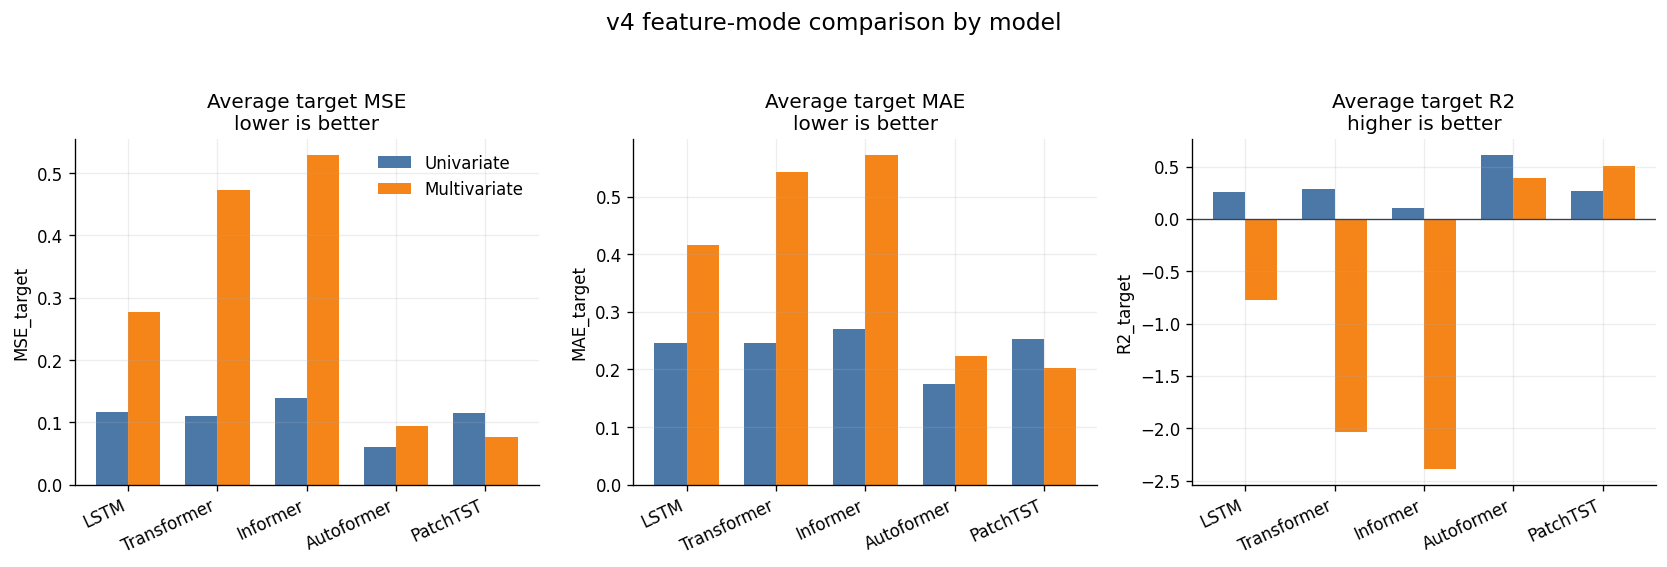

,model,feature_mode,MSE_target,MAE_target,R2_target,train_time_seconds,model_params
1,autoformer,univariate,0.0603,0.1754,0.6131,1116.2,109915
6,patchtst,multivariate,0.0772,0.2030,0.5055,490.4,113037
0,autoformer,multivariate,0.0949,0.2234,0.3920,664.9,110689
9,transformer,univariate,0.1111,0.2454,0.2876,440.8,233274
7,patchtst,univariate,0.1146,0.2537,0.2652,448.6,113037
5,lstm,univariate,0.1165,0.2468,0.2529,830.5,365549
3,informer,univariate,0.1397,0.2710,0.1036,798.7,192110
4,lstm,multivariate,0.2774,0.4152,-0.7777,353.9,578938
8,transformer,multivariate,0.4728,0.5428,-2.0344,343.2,338067
2,informer,multivariate,0.5283,0.5712,-2.3900,486.3,192884


In [3]:
# 每个模型×输入模式包含 10 个任务，按相同任务范围计算平均目标指标和资源统计。
model_mode_avg = (
    df.groupby(["model", "feature_mode"], as_index=False)
    .agg(
        MSE_target=("MSE_target", "mean"),
        MAE_target=("MAE_target", "mean"),
        R2_target=("R2_target", "mean"),
        train_time_seconds=("train_time_seconds", "sum"),
        model_params=("model_params", "mean"),
    )
)

# 三张图分别展示 MSE、MAE 和 R2；固定模型位置后，同一对柱可直接比较输入模式。
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
x = np.arange(len(MODEL_ORDER))
width = 0.36
specs = [
    ("MSE_target", "Average target MSE", "lower is better"),
    ("MAE_target", "Average target MAE", "lower is better"),
    ("R2_target", "Average target R2", "higher is better"),
]

# 两种模式围绕同一模型位置左右偏移，颜色只编码模式，不编码性能高低。
for ax, (metric, title, subtitle) in zip(axes, specs):
    for offset, mode in [(-width / 2, "univariate"), (width / 2, "multivariate")]:
        values = (
            model_mode_avg[model_mode_avg["feature_mode"] == mode]
            .set_index("model")
            .reindex(MODEL_ORDER)[metric]
        )
        ax.bar(x + offset, values, width, label=MODE_LABELS[mode], color=MODE_COLORS[mode])
    ax.set_title(f"{title}\n{subtitle}")
    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABELS[m] for m in MODEL_ORDER], rotation=25, ha="right")
    ax.set_ylabel(metric)
    # R2 可能小于 0；判断必须放在指标循环内部，避免依赖 specs 的最后一个元素。
    if metric == "R2_target":
        ax.axhline(0, color="#374151", linewidth=0.8)

axes[0].legend(frameon=False)
fig.suptitle("v4 feature-mode comparison by model", y=1.04, fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "v4_feature_mode_model_metrics.png", bbox_inches="tight")
plt.show()

display(model_mode_avg.sort_values("MSE_target").style.format({
    "MSE_target": "{:.4f}", "MAE_target": "{:.4f}", "R2_target": "{:.4f}",
    "train_time_seconds": "{:.1f}", "model_params": "{:.0f}",
}))

## 4. 五个预测步长下的目标变量 MSE 趋势

四张子图分别固定一个数据集和输入模式，再比较五个模型随 horizon 增大的变化。

这种布局能够分开观察：

- 模型在长步长预测中的自然误差累积；
- 切换输入模式后曲线高度和斜率的变化；
- 某个模型的多变量优势是否只出现在特定数据集或步长。

曲线不能跨不同子图只凭视觉高度比较，需结合共享的 MSE 数值和后续差值热力图。


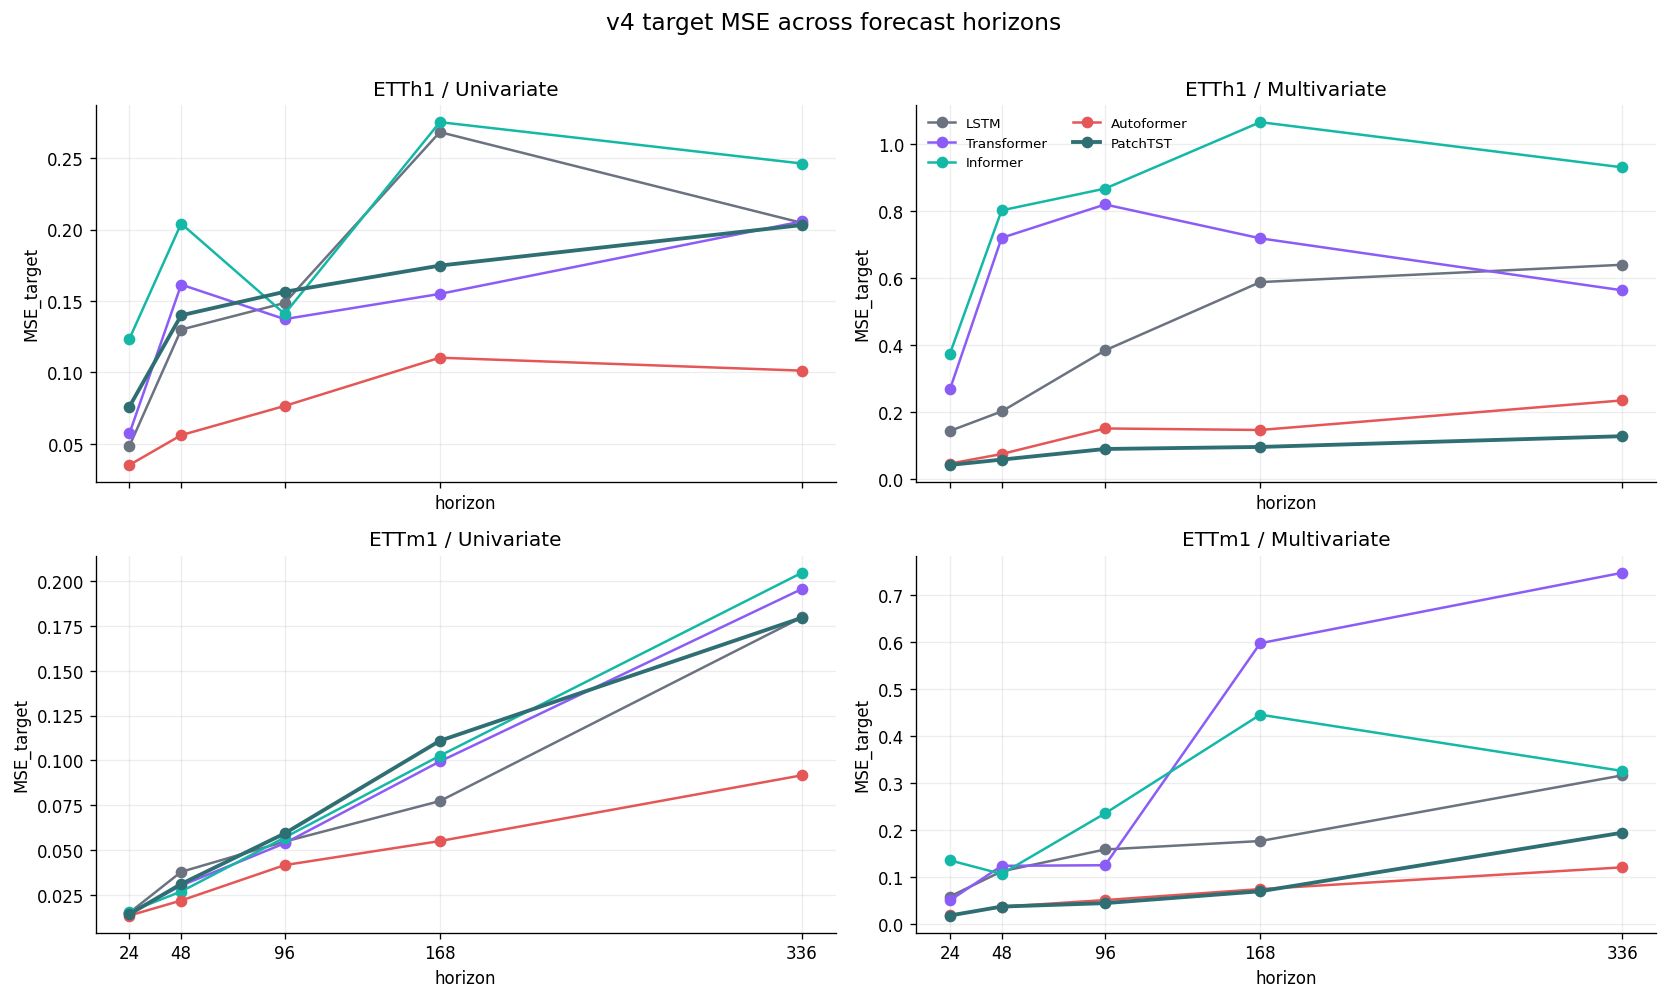

In [4]:
# 行固定数据集、列固定输入模式，使读者能沿行比较模式、沿列比较数据集。
fig, axes = plt.subplots(2, 2, figsize=(14, 8.2), sharex=True)
# 每条曲线只连接同一模型的五个 horizon，显式排序避免折线按 CSV 原始顺序连接。
for row, dataset in enumerate(sorted(df["dataset"].unique())):
    for col, mode in enumerate(MODE_ORDER):
        ax = axes[row, col]
        subset = df[(df["dataset"] == dataset) & (df["feature_mode"] == mode)]
        for model in MODEL_ORDER:
            group = subset[subset["model"] == model].sort_values("horizon")
            ax.plot(
                group["horizon"], group["MSE_target"], marker="o",
                # PatchTST 是多变量收益最明显的模型，适度加粗便于追踪，但不改变任何统计结果。
linewidth=2.3 if model == "patchtst" else 1.5,
                color=MODEL_COLORS[model], label=MODEL_LABELS[model],
            )
        ax.set_title(f"{dataset} / {MODE_LABELS[mode]}")
        ax.set_xticks(EXPECTED_HORIZONS)
        ax.set_xlabel("horizon")
        ax.set_ylabel("MSE_target")

axes[0, 1].legend(fontsize=8, frameon=False, ncol=2)
fig.suptitle("v4 target MSE across forecast horizons", y=1.01, fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "v4_feature_mode_horizon_trends.png", bbox_inches="tight")
plt.show()

## 5. 多变量相对单变量的收益热力图

热力图直接展示 50 个配对的 `delta_MSE_target_pct`，是判断跨变量信息利用能力的核心图。

- 蓝色、正值：多变量更好；
- 红色、负值：单变量更好；
- 颜色越深：两种模式差距越大。

这里特意使用未反转的 `RdBu`：Matplotlib 将负值映射为红色、正值映射为蓝色，正好对应“红色=单变量更好、蓝色=多变量更好”。两个数据集共用对称颜色范围，可以直接比较同一变化幅度。百分比可能受较小的单变量基线 MSE 放大，因此报告中最好同时引用绝对 MSE 或模型平均图。


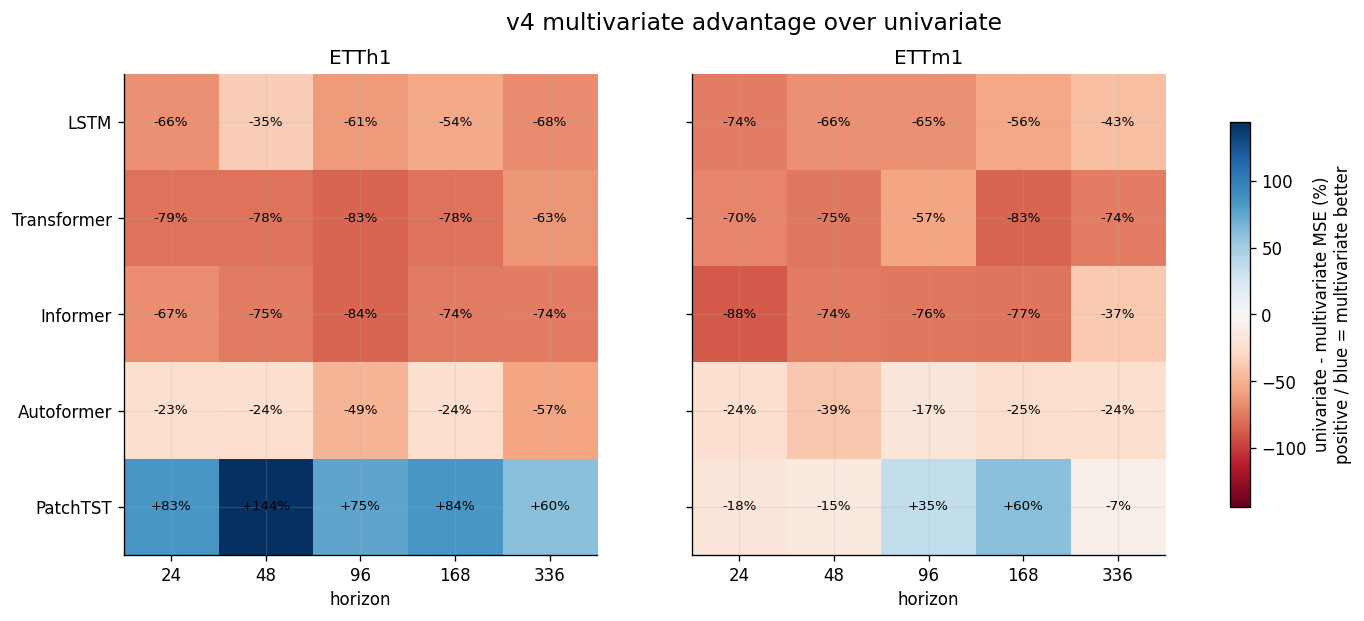

In [5]:
# 两个数据集分别绘图，共用模型顺序、horizon 顺序和同一个颜色范围。
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
# 以最大绝对收益构造关于 0 对称的色标，使正负同幅变化使用相同颜色强度。
max_abs = abs(delta["delta_MSE_target_pct"]).max()

# 将配对长表透视为 model×horizon 矩阵；每个单元格代表一个严格匹配的模式对比。
for ax, dataset in zip(axes, sorted(delta["dataset"].unique())):
    pivot = (
        delta[delta["dataset"] == dataset]
        .pivot(index="model", columns="horizon", values="delta_MSE_target_pct")
        .reindex(MODEL_ORDER)[EXPECTED_HORIZONS]
    )
    # Matplotlib 的 RdBu：负值为红色，正值为蓝色。
    # 当前差值定义为 univariate - multivariate，因此蓝色/正值表示多变量更好。
    im = ax.imshow(pivot.values, aspect="auto", cmap="RdBu", vmin=-max_abs, vmax=max_abs)
    ax.set_title(dataset)
    ax.set_xticks(range(len(EXPECTED_HORIZONS)))
    ax.set_xticklabels(EXPECTED_HORIZONS)
    ax.set_yticks(range(len(MODEL_ORDER)))
    ax.set_yticklabels([MODEL_LABELS[m] for m in MODEL_ORDER])
    ax.set_xlabel("horizon")
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.iloc[i, j]:+.0f}%", ha="center", va="center", fontsize=8)

# 在颜色条中直接写出差值定义和正值含义，避免仅凭红蓝直觉判断。
fig.colorbar(
    im,
    ax=axes.ravel().tolist(),
    shrink=0.8,
    label="univariate - multivariate MSE (%)\npositive / blue = multivariate better",
)
fig.suptitle("v4 multivariate advantage over univariate", y=0.98, fontsize=14)
fig.savefig(FIG_DIR / "v4_feature_mode_delta_heatmap.png", bbox_inches="tight")
plt.show()

## 6. 每个任务的最优模型与胜出次数

每个 `dataset × horizon` 任务分别选择：

- 单变量模式内部的最佳模型；
- 多变量模式内部的最佳模型；
- 跨两种模式的总体最佳组合。

胜出次数适合概括稳定性，但不会体现领先幅度。总体冠军还同时包含模型和输入模式，应避免只写模型名称而遗漏输入口径。


,dataset,horizon,best_univariate,univariate_MSE_target,best_multivariate,multivariate_MSE_target,best_overall,overall_MSE_target
0,ETTh1,24,Autoformer,0.0352,PatchTST,0.0415,Autoformer / Univariate,0.0352
1,ETTh1,48,Autoformer,0.0560,PatchTST,0.0574,Autoformer / Univariate,0.0560
2,ETTh1,96,Autoformer,0.0765,PatchTST,0.0892,Autoformer / Univariate,0.0765
3,ETTh1,168,Autoformer,0.1103,PatchTST,0.0952,PatchTST / Multivariate,0.0952
4,ETTh1,336,Autoformer,0.1012,PatchTST,0.1273,Autoformer / Univariate,0.1012
5,ETTm1,24,Autoformer,0.0137,PatchTST,0.0175,Autoformer / Univariate,0.0137
6,ETTm1,48,Autoformer,0.0220,Autoformer,0.0362,Autoformer / Univariate,0.0220
7,ETTm1,96,Autoformer,0.0417,PatchTST,0.0439,Autoformer / Univariate,0.0417
8,ETTm1,168,Autoformer,0.0551,PatchTST,0.0692,Autoformer / Univariate,0.0551
9,ETTm1,336,Autoformer,0.0918,Autoformer,0.1201,Autoformer / Univariate,0.0918


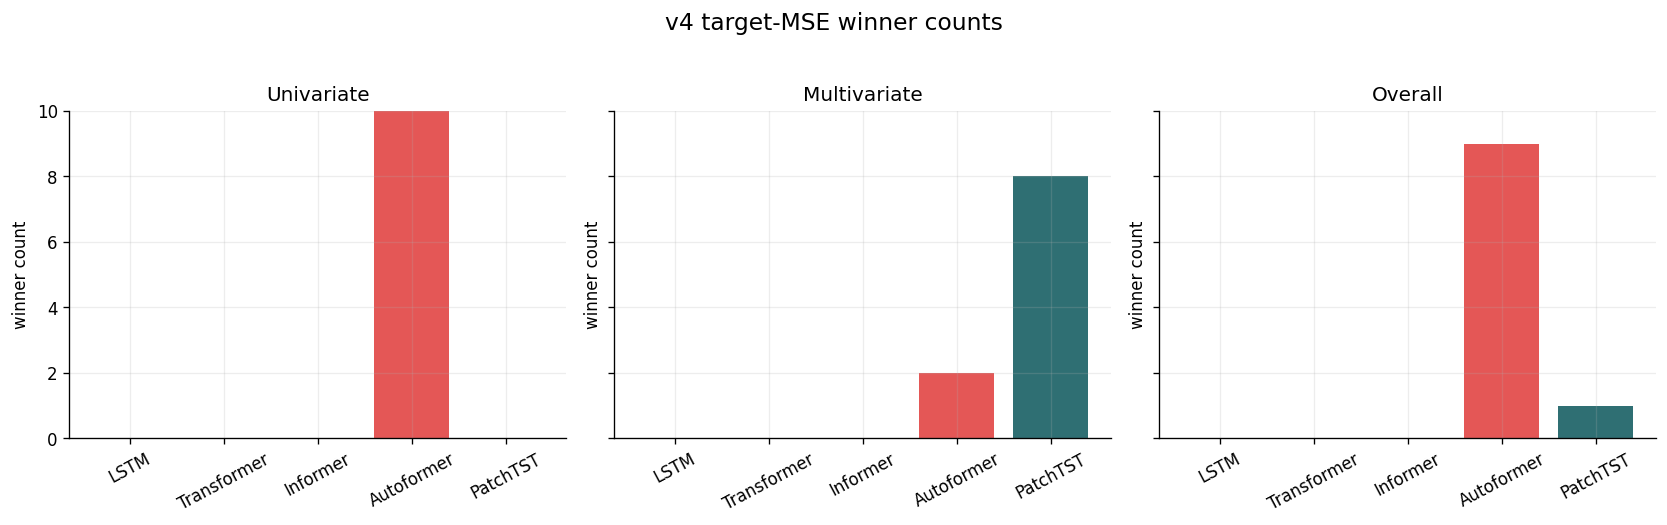

,scope,winner,count
2,Multivariate,PatchTST,8
3,Multivariate,Autoformer,2
1,Overall,Autoformer,9
4,Overall,PatchTST,1
0,Univariate,Autoformer,10


In [6]:
# winner_rows 保存每个任务的详细冠军，count_rows 用于后续三种范围的胜出次数统计。
winner_rows = []
count_rows = []
# 先在单变量和多变量内部各找一次冠军，再在十条记录中寻找总体冠军。
for (dataset, horizon), group in df.groupby(["dataset", "horizon"]):
    row = {"dataset": dataset, "horizon": int(horizon)}
    for mode in MODE_ORDER:
        mode_group = group[group["feature_mode"] == mode]
        best = mode_group.loc[mode_group["MSE_target"].idxmin()]
        row[f"best_{mode}"] = MODEL_LABELS[best["model"]]
        row[f"{mode}_MSE_target"] = best["MSE_target"]
        count_rows.append({"scope": MODE_LABELS[mode], "winner": MODEL_LABELS[best["model"]]})
    overall = group.loc[group["MSE_target"].idxmin()]
    row["best_overall"] = f"{MODEL_LABELS[overall['model']]} / {MODE_LABELS[overall['feature_mode']]}"
    row["overall_MSE_target"] = overall["MSE_target"]
    count_rows.append({"scope": "Overall", "winner": MODEL_LABELS[overall["model"]]})
    winner_rows.append(row)

winners = pd.DataFrame(winner_rows).sort_values(["dataset", "horizon"])
display(winners.style.format({
    "univariate_MSE_target": "{:.4f}",
    "multivariate_MSE_target": "{:.4f}",
    "overall_MSE_target": "{:.4f}",
}))

# value_counts 只返回实际出现的冠军；reindex 会把从未获胜的模型补为 0。
counts = pd.DataFrame(count_rows).value_counts(["scope", "winner"]).rename("count").reset_index()
scopes = ["Univariate", "Multivariate", "Overall"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
# 三张图共用 y 轴上限 10，因为每个 scope 都对应 10 个 dataset×horizon 任务。
for ax, scope in zip(axes, scopes):
    subset = (
        counts[counts["scope"] == scope]
        .set_index("winner")
        .reindex([MODEL_LABELS[m] for m in MODEL_ORDER], fill_value=0)
    )
    ax.bar(subset.index, subset["count"], color=[MODEL_COLORS[m] for m in MODEL_ORDER])
    ax.set_title(scope)
    ax.set_ylabel("winner count")
    ax.tick_params(axis="x", rotation=28)
    ax.set_ylim(0, 10)

fig.suptitle("v4 target-MSE winner counts", y=1.03, fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "v4_feature_mode_winner_counts.png", bbox_inches="tight")
plt.show()
display(counts.sort_values(["scope", "count"], ascending=[True, False]))

## 7. 各模型的多变量收益次数

每个模型恰好有 10 个配对任务。堆叠柱将其拆为：

- 多变量 MSE 更低的任务数；
- 单变量 MSE 更低的任务数。

该图比总体平均更能回答“某个模型是否稳定利用额外变量”。但 6:4 和 10:0 的稳定性不同，仍应结合热力图中的改善幅度。


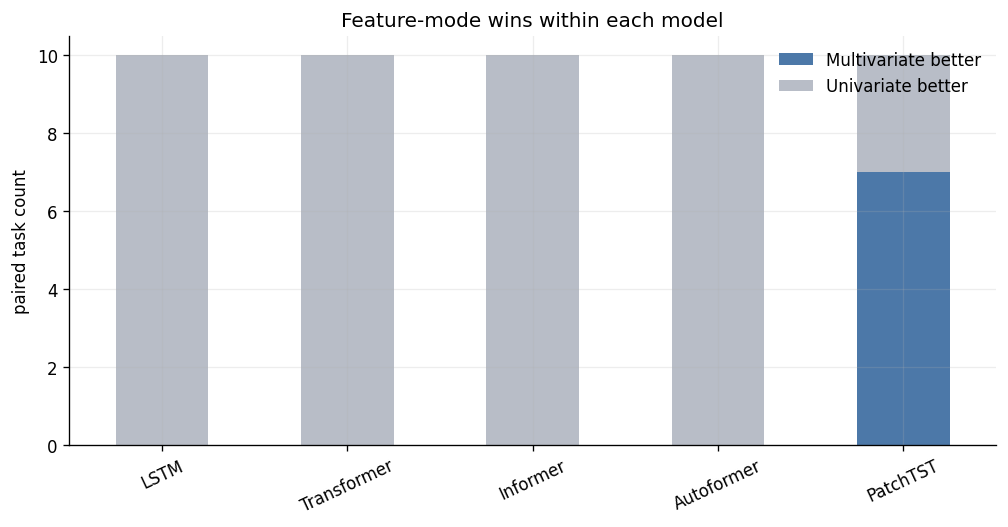

,multivariate_wins,total,univariate_wins
model,,,
lstm,0,10,10
transformer,0,10,10
informer,0,10,10
autoformer,0,10,10
patchtst,7,10,3


In [7]:
# 对每个模型的 10 个配对任务统计 delta>0 的次数，即多变量胜出次数。
benefit_counts = (
    delta.assign(multivariate_better=delta["delta_MSE_target"] > 0)
    .groupby("model")["multivariate_better"]
    .agg(multivariate_wins="sum", total="count")
    .reindex(MODEL_ORDER)
)
# 每个配对不存在平局时，单变量胜出次数可由总数减去多变量胜出次数得到。
benefit_counts["univariate_wins"] = benefit_counts["total"] - benefit_counts["multivariate_wins"]

# 堆叠柱总高度固定为 10，能直接比较各模型对多变量信息的稳定利用程度。
plot_counts = benefit_counts[["multivariate_wins", "univariate_wins"]].copy()
plot_counts.index = [MODEL_LABELS[m] for m in plot_counts.index]
ax = plot_counts.plot(
    kind="bar", stacked=True, figsize=(8.5, 4.5),
    color=["#4C78A8", "#B8BDC7"],
)
ax.set_title("Feature-mode wins within each model")
ax.set_xlabel("")
ax.set_ylabel("paired task count")
ax.tick_params(axis="x", rotation=25)
ax.legend(["Multivariate better", "Univariate better"], frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "v4_feature_mode_benefit_counts.png", bbox_inches="tight")
plt.show()
display(benefit_counts.astype(int))

## 8. 误差、训练时间与参数量权衡

每个点代表一个“模型 × 输入模式”组合：

- 横轴：完成对应模式全部任务的总训练时间，使用对数坐标；
- 纵轴：平均目标变量 MSE；
- 点面积：平均参数量；
- 圆点/方块：区分单变量和多变量。

训练时间受 GPU、早停和数据吞吐影响，只适合本批实验内部比较。单变量模型参数量略有变化，是因为输入/输出维度不同，不应仅按点面积判断结构复杂度。


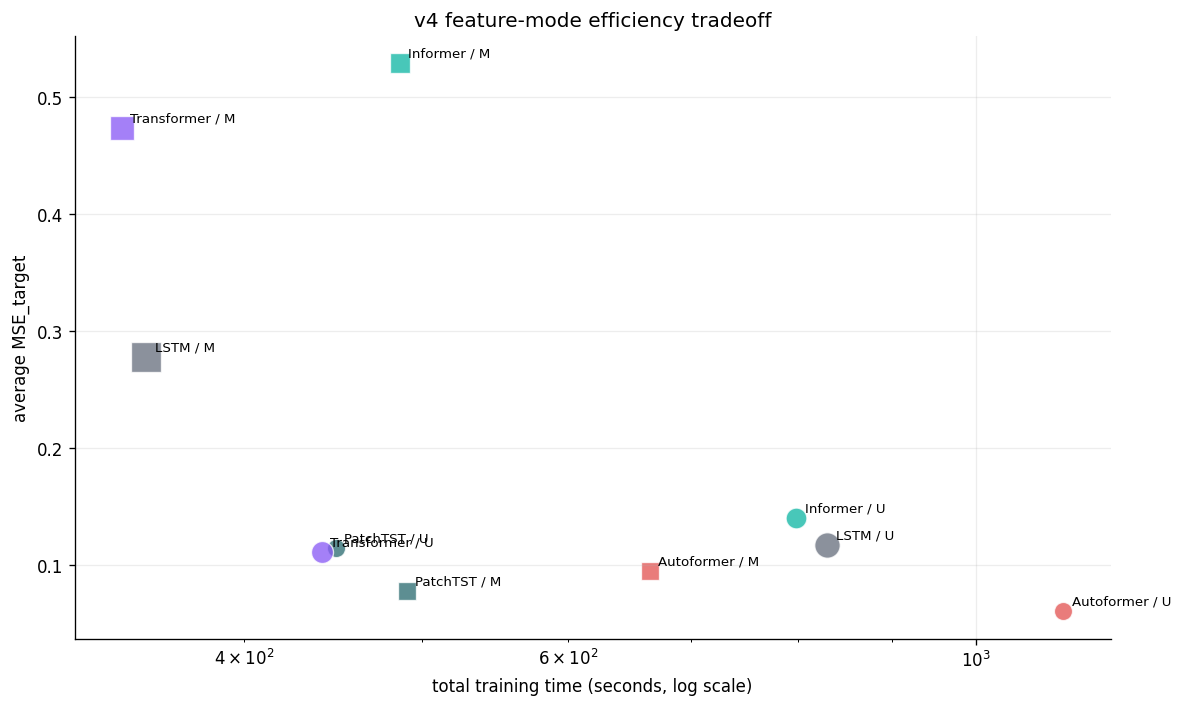

In [8]:
# 每个散点代表一个模型×输入模式组合，共 10 个点。
eff = model_mode_avg.copy()
fig, ax = plt.subplots(figsize=(10, 6))
# 颜色编码模型，点形编码输入模式，点面积编码参数量，避免单一视觉通道承担过多含义。
for _, row in eff.iterrows():
    model = row["model"]
    mode = row["feature_mode"]
    marker = "o" if mode == "univariate" else "s"
    size = 70 + row["model_params"] / eff["model_params"].max() * 260
    ax.scatter(
        row["train_time_seconds"], row["MSE_target"],
        s=size, marker=marker, color=MODEL_COLORS[model],
        alpha=0.78, edgecolor="white", linewidth=0.8,
    )
    ax.annotate(
        f"{MODEL_LABELS[model]} / {MODE_LABELS[mode][0]}",
        (row["train_time_seconds"], row["MSE_target"]),
        xytext=(5, 4), textcoords="offset points", fontsize=8,
    )

# 训练时间跨度较大，使用对数横轴可避免耗时较短的点挤在一起。
ax.set_xscale("log")
ax.set_title("v4 feature-mode efficiency tradeoff")
ax.set_xlabel("total training time (seconds, log scale)")
ax.set_ylabel("average MSE_target")
fig.tight_layout()
fig.savefig(FIG_DIR / "v4_feature_mode_efficiency_tradeoff.png", bbox_inches="tight")
plt.show()

## 9. 自动结论与输出文件

自动结论报告最佳模型—模式组合、多变量获胜总数、最能利用多变量的模型，以及 10 个任务的总体冠军模式分布。

这些文字是事实摘要，不替代结构解释。正式报告可以结合消融结果讨论 PatchTST 的 Patching 和 Channel Independence 为什么更适合利用多变量信息，同时指出其他模型可能受到噪声变量、目标不一致或参数选择的影响。


In [9]:
# 直接从模型×模式平均表寻找平均目标 MSE 最低的组合。
best_combo = model_mode_avg.sort_values("MSE_target").iloc[0]
# 同时统计每个模型的平均多变量收益和多变量获胜次数，兼顾幅度与稳定性。
model_delta = (
    delta.groupby("model", as_index=False)
    .agg(
        mean_delta_pct=("delta_MSE_target_pct", "mean"),
        multivariate_wins=("delta_MSE_target", lambda x: int((x > 0).sum())),
    )
    .sort_values("mean_delta_pct", ascending=False)
)
most_multi = model_delta.iloc[0]
# 每个 dataset×horizon 只保留目标 MSE 最低的一行，用于统计总体冠军属于哪种输入模式。
overall_best_rows = df.loc[df.groupby(["dataset", "horizon"])["MSE_target"].idxmin()]
overall_mode_counts = overall_best_rows["feature_mode"].value_counts()

# 自动结论限定为可由表格直接验证的描述，模型机制解释留给 Markdown 和正式报告。
report_lines = [
    f"v4 单/多变量实验包含 {len(df)} 条明细和 {len(delta)} 个同模型配对，覆盖全部五个预测步长。",
    f"按跨任务平均目标变量 MSE，最佳组合是 {MODEL_LABELS[best_combo['model']]} / {MODE_LABELS[best_combo['feature_mode']]}，MSE_target={best_combo['MSE_target']:.4f}。",
    f"多变量在 {multi_better}/50 个配对中胜出；单变量在 {50 - multi_better}/50 个配对中胜出。",
    f"最能利用多变量输入的是 {MODEL_LABELS[most_multi['model']]}：10 个任务中多变量胜出 {int(most_multi['multivariate_wins'])} 次，平均收益 {most_multi['mean_delta_pct']:+.1f}%。",
    f"10 个 dataset-horizon 总体冠军中，单变量模式占 {int(overall_mode_counts.get('univariate', 0))} 次，多变量模式占 {int(overall_mode_counts.get('multivariate', 0))} 次。",
]
display(Markdown("\n".join(f"- {line}" for line in report_lines)))

outputs = [
    "v4_feature_mode_model_metrics.png",
    "v4_feature_mode_horizon_trends.png",
    "v4_feature_mode_delta_heatmap.png",
    "v4_feature_mode_winner_counts.png",
    "v4_feature_mode_benefit_counts.png",
    "v4_feature_mode_efficiency_tradeoff.png",
]
display(Markdown("**Saved figures**\n\n" + "\n".join(f"- `{name}`" for name in outputs)))

- v4 单/多变量实验包含 100 条明细和 50 个同模型配对，覆盖全部五个预测步长。
- 按跨任务平均目标变量 MSE，最佳组合是 Autoformer / Univariate，MSE_target=0.0603。
- 多变量在 7/50 个配对中胜出；单变量在 43/50 个配对中胜出。
- 最能利用多变量输入的是 PatchTST：10 个任务中多变量胜出 7 次，平均收益 +50.1%。
- 10 个 dataset-horizon 总体冠军中，单变量模式占 9 次，多变量模式占 1 次。

**Saved figures**

- `v4_feature_mode_model_metrics.png`
- `v4_feature_mode_horizon_trends.png`
- `v4_feature_mode_delta_heatmap.png`
- `v4_feature_mode_winner_counts.png`
- `v4_feature_mode_benefit_counts.png`
- `v4_feature_mode_efficiency_tradeoff.png`